# Evaluation
- Runs each model (LSTM + ablations, benchmarks) across all rolling origins and saves forecast tables
- Re-indexes origin-indexed forecasts to target-date-indexed tables and adds the ifo institutional forecast
- Computes MSE, RMSE, (squared) bias and error variance over the full test set
- Exports comparison and regularisation-ablation tables, then repeats the evaluation excluding 2020

# Imports, configuaration, helpers

In [1]:
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.lstm import lstm
from models.benchmarks import mean_method, ar1, naive_method
from config import RESULTS_DIR, TARGET, HORIZONS, ORIGINS, DATA_PATH, TEX_DATA_DIR

In [2]:
def run_forecasts(model_fn, name):
    '''
    - calls model_fn(max(HORIZONS), origin) at each rolling origin
    - supports both 2-tuple (preds, diagnostics) and 3-tuple (preds, all_preds, diagnostics) returns
    - stores origin-indexed forecasts, then re-indexes to target dates (row t = forecast targeting t)
    - exports forecast table to csv; if multi-seed, also exports per-seed forecasts
    '''
    columns = [f'{h} step forecast' for h in HORIZONS]
    df = pd.DataFrame(index=ORIGINS, columns=columns, dtype=float)
    per_seed_records = []

    for i, origin in enumerate(ORIGINS, start=1):
        result = model_fn(max(HORIZONS), origin)

        # 3-tuple: multi-seed ensemble; 2-tuple: single model
        if len(result) == 3:
            preds, all_preds, all_diagnostics = result
            for seed_idx, seed_preds in enumerate(all_preds):
                per_seed_records.append({
                    'origin': origin,
                    'seed_idx': seed_idx,
                    **{f'{h} step forecast': p for h, p in zip(HORIZONS, seed_preds)},
                })
            best_epochs = [d['best_epoch'] for d in all_diagnostics if 'best_epoch' in d]
            diag_str = (f' | best epoch: mean {np.mean(best_epochs):.0f}, std {np.std(best_epochs):.0f}'
                        if best_epochs else '')
        else:
            preds, diagnostics = result
            diag_str = (f' | best epoch: {diagnostics["best_epoch"]}'
                        if isinstance(diagnostics, dict) and 'best_epoch' in diagnostics else '')

        df.loc[origin] = preds
        print(f'  {i}/{len(ORIGINS)} | origin: {origin:%Y-%m-%d} | '
              f'preds: {[f"{p:.4f}" for p in preds]}{diag_str}')

    # convert origin-indexed to target-indexed: shift column h by h rows
    df.index = ORIGINS + pd.DateOffset(months=3)
    df.index.name = 'target_date'
    for i, col in enumerate(columns):
        df[col] = df[col].shift(i)

    df.to_csv(RESULTS_DIR / f'{name}_forecasts.csv')
    if per_seed_records:
        pd.DataFrame(per_seed_records).to_csv(RESULTS_DIR / f'{name}_forecasts_per_seed.csv', index=False)

    return df


def evaluate(tables, data):
    '''
    - aligns predictions to actuals by target_date and drops missing target periods
    - computes per-horizon error metrics (rmse, bias, err_var, mse, bias2) per model
    '''
    metrics = ['rmse', 'bias', 'err_var', 'mse', 'bias2']
    columns = [f'{h} step {m}' for h in HORIZONS for m in metrics]
    df = pd.DataFrame(index=list(tables.keys()), columns=columns, dtype=float)

    target_series = data.assign(t=pd.to_datetime(data['t'])).set_index('t')[TARGET]

    for name, table in tables.items():
        for col in table.columns:
            h = int(col.split()[0])
            preds = table[col]
            err = (preds - target_series.reindex(preds.index)).dropna()
            df.loc[name, f'{h} step rmse'] = np.sqrt((err ** 2).mean())
            df.loc[name, f'{h} step bias'] = err.mean()
            df.loc[name, f'{h} step err_var'] = err.var(ddof=0)
            df.loc[name, f'{h} step mse'] = (err ** 2).mean()
            df.loc[name, f'{h} step bias2'] = err.mean() ** 2
    return df


def export_metric(results, metric, model_order, filename):
    '''
    - selects all columns ending with 'metric' from results, transposes to horizon-indexed
    - reorders rows to model_order, sets index name 'horizon', writes to TEX_DATA_DIR
    '''
    cols = [c for c in results.columns if c.endswith(metric)]
    out = results[cols].T.loc[:, model_order]
    out.index = out.index.str[0]
    out.index.name = 'horizon'
    out.to_csv(TEX_DATA_DIR / filename, float_format='%.4f')
    return out


def plot_error_metrics(results):
    '''
    - 2x2 grid of rmse, mse, bias2, err_var vs forecast horizon, one line per model
    - dashed zero line on the bias panel
    '''
    metrics = ['rmse', 'mse', 'bias2', 'err_var']
    labels = {'rmse': 'RMSE', 'mse': 'MSE', 'bias2': 'Bias2', 'err_var': 'Error variance'}

    fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True)
    axes = axes.flatten()
    for ax, metric in zip(axes, metrics):
        cols = [c for c in results.columns if c.endswith(f' {metric}')]
        horizons = [int(c.split()[0]) for c in cols]
        for name, row in results[cols].iterrows():
            ax.plot(horizons, row.values, marker='o', label=name)
        ax.set_xlabel('Forecast horizon (quarters ahead)')
        ax.set_ylabel(labels[metric])
        ax.set_title(f'{labels[metric]} vs forecast horizon')
        ax.set_xticks(horizons)
        if metric == 'bias':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    axes[0].legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_forecasts_by_horizon(tables, data, start='2019-04-01'):
    '''
    - one panel per model: actuals vs forecasts, one line per horizon
    - viridis colormap, horizons sorted ascending
    '''
    target_series = (data.assign(t=pd.to_datetime(data['t']))
                         .set_index('t')[TARGET].loc[start:])

    for name, table in tables.items():
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(target_series.index, target_series.values,
                color='black', linewidth=2, label='Actual', zorder=10)

        horizon_cols = sorted(table.columns, key=lambda c: int(c.split()[0]))
        cmap = plt.cm.viridis(np.linspace(0, 0.85, len(horizon_cols)))
        for col, color in zip(horizon_cols, cmap):
            h = int(col.split()[0])
            series = table[col].dropna()
            ax.plot(series.index, series.values, marker='o', markersize=4,
                    linewidth=1.2, color=color, alpha=0.85, label=f'{h}-step')

        ax.set_xlabel('Target date')
        ax.set_ylabel(TARGET)
        ax.set_title(f'{name}: forecasts by horizon vs. actuals')
        ax.legend(loc='best', fontsize=9, ncol=2)
        plt.tight_layout()
        plt.show()

# Run Forecasts

In [ ]:
# run forecasts for every model
models = {
    'lstm':                   partial(lstm, n_models=5, early_stopping=True),
    'lstm_wo_ensembling':     partial(lstm, n_models=1, early_stopping=True),
    'lstm_wo_early_stopping': partial(lstm, n_models=5, early_stopping=False),
    'mean_method':            mean_method,
    'ar1':                    ar1,
    'naive_method':           naive_method,
}
tables = {name: run_forecasts(fn, name) for name, fn in models.items()}

In [ ]:
# add ifo institutional forecast
ifo = pd.read_csv(RESULTS_DIR / 'ifo_forecasts.csv', index_col='t', parse_dates=['t'])
ifo.index.name = 'target_date'
tables['ifo'] = ifo

# cut forecasts due to missing values before 2019-04-01
CUTOFF = '2019-04-01'
tables = {name: df.loc[CUTOFF:] for name, df in tables.items()}

# load actuals and compute metrics
data = pd.read_csv(DATA_PATH)
results = evaluate(tables, data)

results

# Evaluate on full test set

In [ ]:
# performance comparison (rmse) across models
comparison_order = ['lstm', 'mean_method', 'ar1', 'naive_method', 'ifo']
export_metric(results, 'rmse', comparison_order, 'results_perfomance_comparison_full.csv')

,lstm_full,historical_mean,ar1,naive_method,ifo
horizon,,,,,
1,2.488734,2.506764,2.549938,3.777928,1.336156
2,2.513897,2.503792,2.501119,3.318696,2.447884
3,2.483835,2.506378,2.513716,3.707172,2.599934
4,2.527703,2.504386,2.502302,3.578463,2.534105
5,2.542889,2.503992,2.502229,3.513125,2.506169
6,2.554535,2.504454,2.502452,3.498345,2.544048


In [ ]:
# h=1 forecasts across all models, joined with actuals for chart export
actual = (pd.read_csv(DATA_PATH)[['t', TARGET]]
            .assign(t=lambda d: pd.to_datetime(d['t']))
            .rename(columns={TARGET: 'gdp'}))

forecast_files = {
    'lstm':        'lstm_forecasts.csv',
    'ifo':         'ifo_forecasts.csv',
    'ar1':         'ar1_forecasts.csv',
    'mean':        'mean_method_forecasts.csv',
    'naive':       'naive_method_forecasts.csv',
}

export = actual.copy()
for name, filename in forecast_files.items():
    fc = pd.read_csv(RESULTS_DIR / filename)
    fc['t'] = pd.to_datetime(fc['target_date'])
    fc = fc[['t', '1 step forecast']].rename(columns={'1 step forecast': name})
    export = export.merge(fc, on='t', how='left')

export = export[export['t'] > pd.to_datetime('2019-01-01')].copy()
export['quarter_idx'] = export['t'].dt.year + (export['t'].dt.quarter - 1) / 4
export = export[['t', 'quarter_idx', 'gdp', 'lstm', 'ifo', 'ar1', 'mean', 'naive']]
export.to_csv(TEX_DATA_DIR / 'results_perfomance_comparison_forecast.csv',
              index=False, float_format='%.4f')

export.head()

,t,quarter_idx,gdp,lstm,ifo,ar1,mean,naive
113,2019-04-01,2019.25,0.057511,0.476670,0.30,0.346013,0.368632,0.445788
114,2019-07-01,2019.50,0.383184,0.522038,0.30,0.353409,0.371175,0.656051
115,2019-10-01,2019.75,-0.334001,0.128546,0.10,0.337758,0.368424,0.057511
116,2020-01-01,2020.00,-2.029881,0.222489,0.24,0.345209,0.368552,0.383184
117,2020-04-01,2020.25,-8.874121,0.055587,-4.50,0.323882,0.362496,-0.334001
118,2020-07-01,2020.50,8.676540,0.107733,6.90,0.252498,0.342048,-2.029881
119,2020-10-01,2020.75,0.967137,0.576768,2.75,-1.250046,0.263945,-8.874121
120,2021-01-01,2021.00,-0.615771,0.623756,0.59,0.795454,0.334639,8.676540
121,2021-04-01,2021.25,2.350509,0.400427,2.06,0.336247,0.339910,0.967137
122,2021-07-01,2021.50,0.086478,0.373646,3.56,0.294190,0.332012,-0.615771


In [ ]:
# regularization ablation: mse, bias2, err_var
regularization_order = ['lstm', 'lstm_wo_ensembling', 'lstm_wo_early_stopping']
export_metric(results, 'mse',     regularization_order, 'results_regularization_mse_full.csv')
export_metric(results, 'bias2',   regularization_order, 'results_regularization_bias2_full.csv')
export_metric(results, 'err_var', regularization_order, 'results_regularization_variance_full.csv')

,lstm_full,lstm_wo_ensembling,lstm_wo_early_stopping
horizon,,,
1,6.193799,6.484126,9.719491
2,6.319679,6.982138,7.307799
3,6.169439,5.967343,7.159009
4,6.389285,6.384279,6.950447
5,6.466286,6.814599,6.490329
6,6.525649,7.149281,6.294542


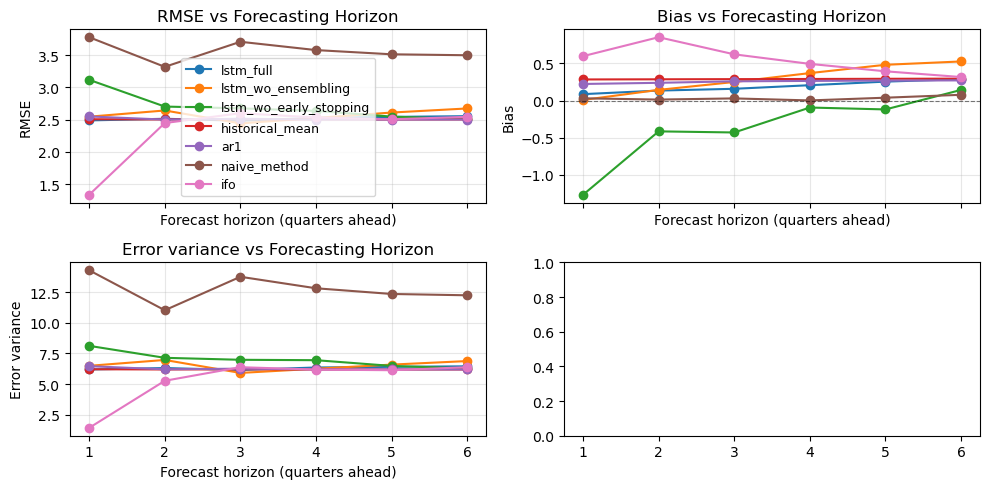

In [ ]:
# validate Results
plot_error_metrics(results)

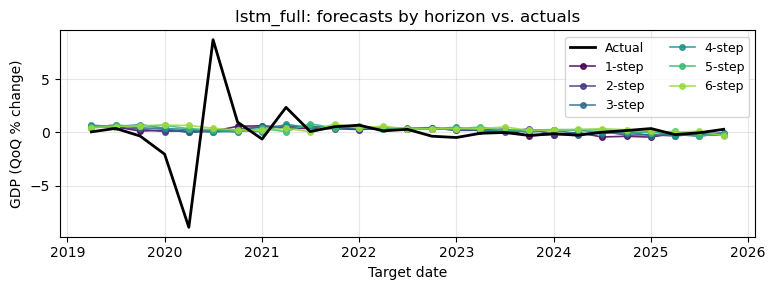

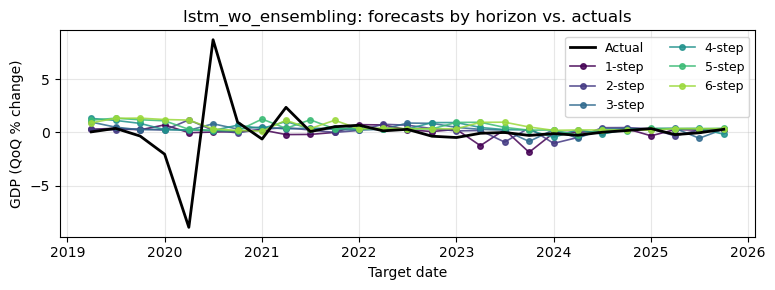

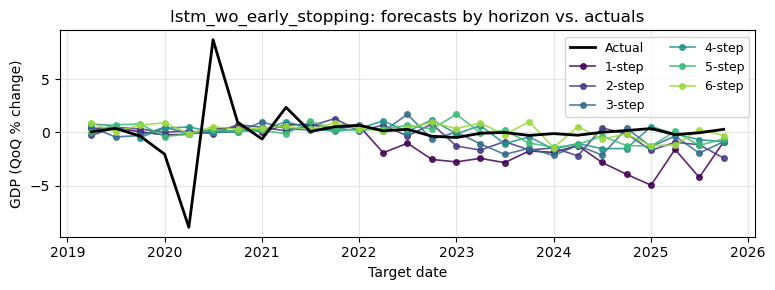

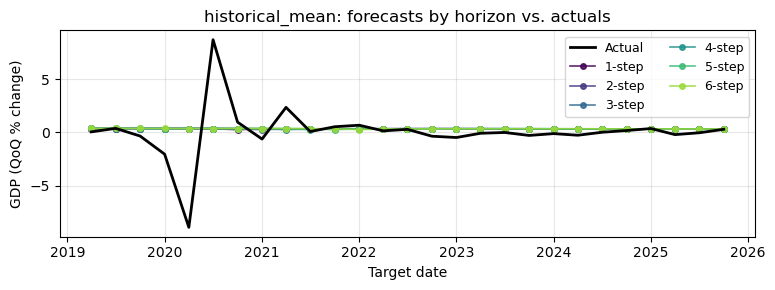

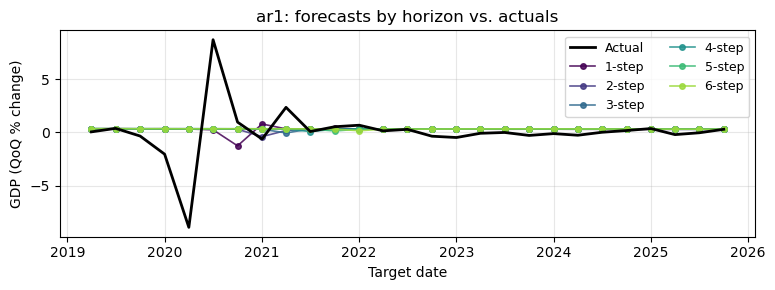

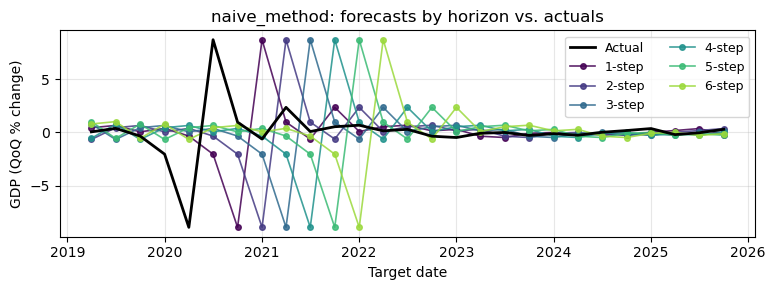

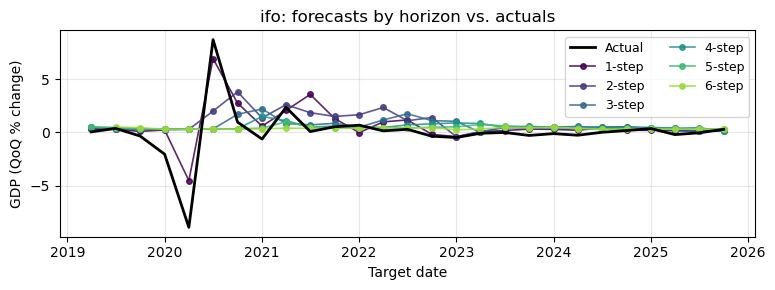

In [ ]:
plot_forecasts_by_horizon(tables, data)

# Evaluate models on test set w/o Covid

In [ ]:
# mask 2020 in every forecast table, then re-evaluate
def mask_covid(df):
    df = df.loc[CUTOFF:].copy()
    df.loc['2020-01-01':'2020-12-31'] = float('nan')
    return df

tables_excl_covid = {name: mask_covid(df) for name, df in tables.items()}
results_excl_covid = evaluate(tables_excl_covid, data)

results_excl_covid

In [ ]:
# evaluate again on this test set
export_metric(results_excl_covid, 'rmse', comparison_order,
              'results_perfomance_comparison_excl_covid.csv')

,1 step rmse,1 step bias,1 step err_var,1 step mse,1 step bias2,2 step rmse,2 step bias,2 step err_var,2 step mse,2 step bias2,...,5 step rmse,5 step bias,5 step err_var,5 step mse,5 step bias2,6 step rmse,6 step bias,6 step err_var,6 step mse,6 step bias2
lstm_full,0.620059,0.005506,0.384443,0.384474,0.000030,0.579652,0.074526,0.330442,0.335996,0.005554,...,0.681760,0.184009,0.430938,0.464797,0.033859,0.618349,0.198009,0.343148,0.382356,0.039208
lstm_wo_ensembling,0.774861,-0.080167,0.593982,0.600409,0.006427,0.643183,0.046851,0.411489,0.413684,0.002195,...,0.878495,0.436063,0.581604,0.771754,0.190151,0.713326,0.438419,0.316622,0.508834,0.192212
lstm_wo_early_stopping,2.213812,-1.559864,2.467787,4.900964,2.433177,1.222037,-0.574192,1.163678,1.493375,0.329697,...,1.035399,-0.186877,1.037128,1.072051,0.034923,0.886399,0.043005,0.783854,0.785704,0.001849
historical_mean,0.612854,0.221540,0.326510,0.375590,0.049080,0.610393,0.219416,0.324436,0.372579,0.048143,...,0.617633,0.225925,0.330428,0.381470,0.051042,0.617340,0.228031,0.329111,0.381109,0.051998
ar1,0.640456,0.222528,0.360666,0.410184,0.049519,0.599852,0.168837,0.331316,0.359822,0.028506,...,0.614574,0.202009,0.336893,0.377701,0.040807,0.613853,0.204494,0.334997,0.376815,0.041818
naive_method,2.033734,0.453422,3.930481,4.136073,0.205592,2.256818,0.045333,5.091173,5.093228,0.002055,...,2.792285,-0.030669,7.795913,7.796854,0.000941,2.852207,-0.016511,8.134813,8.135085,0.000273
ifo,0.874356,0.413711,0.593340,0.764498,0.171157,0.932677,0.671972,0.418339,0.869886,0.451547,...,0.608768,0.351972,0.246714,0.370598,0.123884,0.636309,0.261040,0.336748,0.404889,0.068142


## Validate results

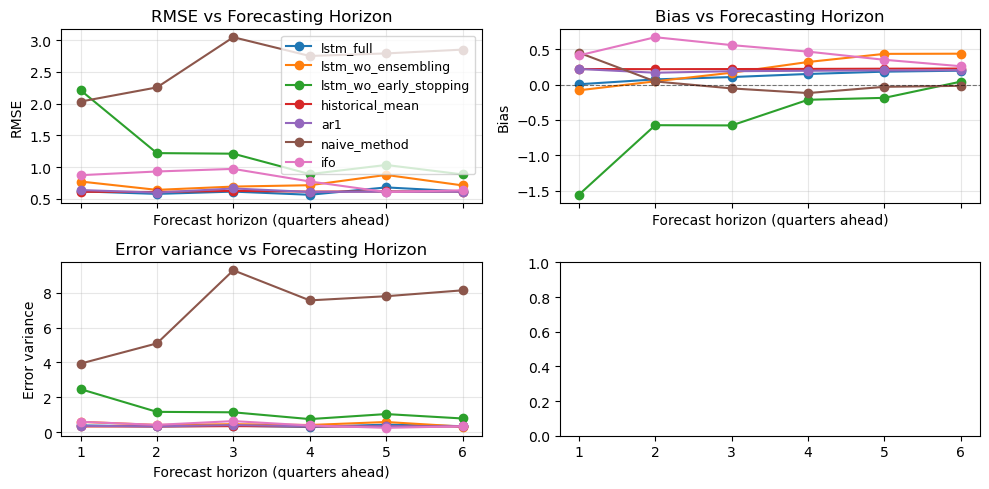

In [ ]:
# validate Results
plot_error_metrics(results_excl_covid)